### Collecting and processing data

In [692]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

df = pd.read_csv('dataset-47695.csv')

df.head()

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,Prof,B,19,18,Male,139750
1,Prof,B,20,16,Male,173200
2,AsstProf,B,4,3,Male,79750
3,Prof,B,45,39,Male,115000
4,Prof,B,40,41,Male,141500


In [693]:
df.drop(['discipline', 'sex', 'yrs.service'],axis=1,inplace=True)
df.head()

,rank,yrs.since.phd,salary
0,Prof,19,139750
1,Prof,20,173200
2,AsstProf,4,79750
3,Prof,45,115000
4,Prof,40,141500


In [694]:
df = df[df['rank'] == 'AssocProf']
df.to_csv('Salla.csv', index = False)

In [695]:
df.describe()

,yrs.since.phd,salary
count,64.000000,64.000000
mean,15.453125,93876.437500
std,9.652584,13831.699844
min,6.000000,62884.000000
25%,10.000000,82475.000000
50%,12.000000,95626.500000
75%,17.250000,104226.250000
max,49.000000,126431.000000


### Calculate mean, variance, and standard deviation

In [696]:
salary = df['salary'].tolist()
yrs_since_phd = df['yrs.since.phd'].tolist()
# numpy use population std, pandas use sample std
# if we use np with ddof = 1 => freedom degree
# the result will be the same as pandas

salary_mean = np.mean(salary)
salary_var = np.var(salary)
salary_std = np.std(salary)

print('Mean of salary: ', salary_mean)
print('Variance of salary: ', salary_var)
print('Std of salary: ', salary_std) 
print() 

yrs_since_phd_mean = np.mean(yrs_since_phd)
yrs_since_phd_var = np.var(yrs_since_phd)
yrs_since_phd_std = np.std(yrs_since_phd)

print('Mean of yrs_since_phd: ', yrs_since_phd_mean)
print('Variance of yrs_since_phd: ', yrs_since_phd_var)
print('Std of yrs_since_phd: ', yrs_since_phd_std)



Mean of salary:  93876.4375
Variance of salary:  188326609.30859375
Std of salary:  13723.21424844026

Mean of yrs_since_phd:  15.453125
Variance of yrs_since_phd:  91.716552734375
Std of yrs_since_phd:  9.576875938132174


### Visualize experience and salary

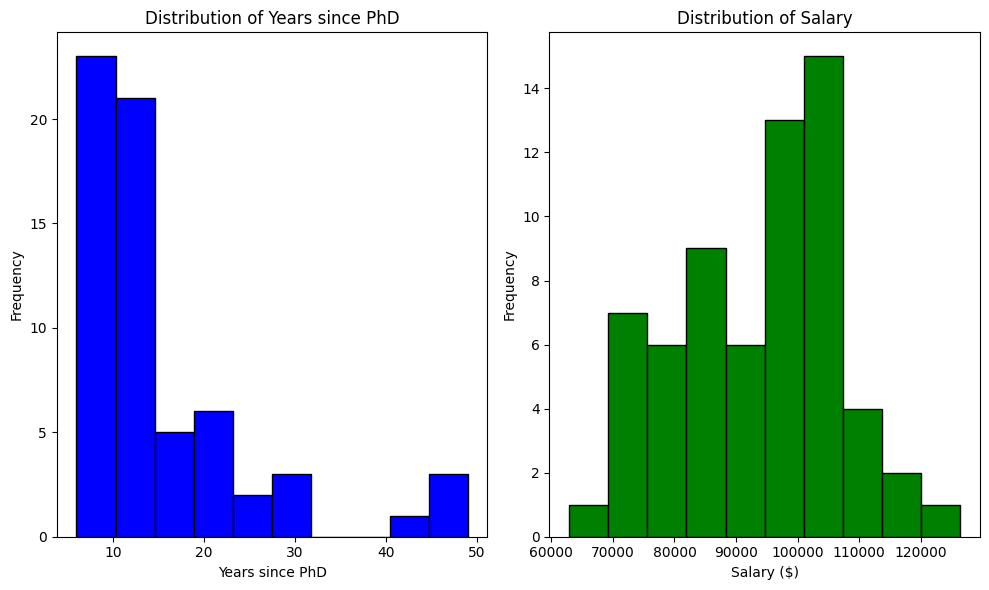

In [697]:
import matplotlib.pyplot as plt

salary = df['salary'].tolist()
yrs_since_phd = df['yrs.since.phd'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

ax1.hist(yrs_since_phd, bins=10, color='blue', edgecolor='black')
ax1.set_xlabel('Years since PhD')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Years since PhD')

ax2.hist(salary, bins=10, color='green', edgecolor='black')
ax2.set_xlabel('Salary ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Salary')

plt.tight_layout()
plt.show()


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


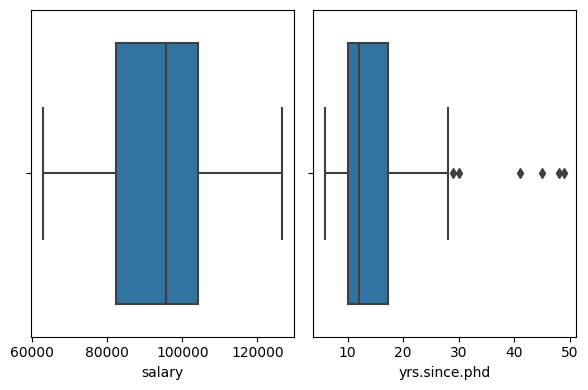

In [698]:
fig, axs = plt.subplots(1, 2, figsize=(6, 4))

plt1 = sns.boxplot(x = df['salary'], ax = axs[0])
plt2 = sns.boxplot(x = df['yrs.since.phd'], ax = axs[1])
plt.tight_layout()
plt.show()

In [699]:
Q1 = df['yrs.since.phd'].quantile(0.25)
Q3 = df['yrs.since.phd'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

upper_array = np.where(df['yrs.since.phd']>=upper)[0]
lower_array = np.where(df['yrs.since.phd']<=lower)[0]

df = df.reset_index(drop=True)

df.drop(index=upper_array, inplace=True)
df.drop(index=lower_array, inplace=True)
df = df.reset_index(drop=True)

df.to_csv('Salla.csv', index = False)


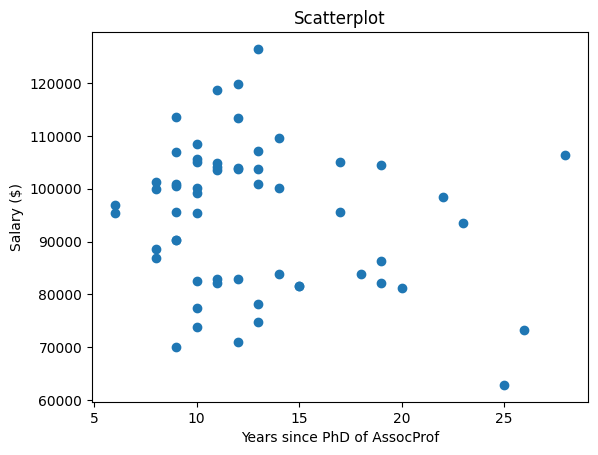

In [700]:
plt.scatter(x = df['yrs.since.phd'], y = df['salary']) 
plt.title('Scatterplot')
plt.xlabel('Years since PhD of AssocProf')
plt.ylabel('Salary ($)')
plt.show()

In [701]:
# df = pd.read_csv('Salla.csv')

# fig, axs = plt.subplots(1, 2, figsize=(6, 4))

# plt1 = sns.boxplot(x = df['salary'], ax = axs[0])
# plt2 = sns.boxplot(x = df['yrs.since.phd'], ax = axs[1])
# plt.tight_layout()
# plt.show()

In [702]:
# Q1 = df['yrs.since.phd'].quantile(0.25)
# Q3 = df['yrs.since.phd'].quantile(0.75)
# IQR = Q3 - Q1
# lower = Q1 - 1.5*IQR
# upper = Q3 + 1.5*IQR

# upper_array = np.where(df['yrs.since.phd']>=upper)[0]
# lower_array = np.where(df['yrs.since.phd']<=lower)[0]

# df = df.reset_index(drop=True)

# df.drop(index=upper_array, inplace=True)
# df.drop(index=lower_array, inplace=True)
# df = df.reset_index(drop=True)

# df.to_csv('Salla.csv', index = False)

In [703]:
# # df = pd.read_csv('Salla.csv')

# fig, axs = plt.subplots(1, 2, figsize=(6, 4))

# plt1 = sns.boxplot(x = df['salary'], ax = axs[0])
# plt2 = sns.boxplot(x = df['yrs.since.phd'], ax = axs[1])
# plt.tight_layout()
# plt.show()

### Testing the hypothesis

In [704]:
import scipy.stats as stats
# assume that Null hypothesis: Mean of Salary of AssocProf in US is 130000$ 
# = > Alternative hypothesis: Mean of Salary of AssocProf in US is not 130000$
# CI = 95% or 0.95
data = df['salary'].tolist()

#perform one sample t-test
stats.ttest_1samp(a=data, popmean=130000)

# after calculate we get p-value = 1.85e-24 << 0.05
# => reject the null hypothesis and fail reject alternative hypothesis.

TtestResult(statistic=-19.52565513996088, pvalue=6.376529585964987e-27, df=57)

### Linear Regression Model

In [705]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

scaler = StandardScaler()

df['salary'] = scaler.fit_transform(df['salary'].values.reshape(-1, 1))
df['yrs.since.phd'] = scaler.fit_transform(df['yrs.since.phd'].values.reshape(-1, 1))
# df['salary'] = np.log10(df['salary'])
# df['yrs.since.phd'] = np.log10(df['yrs.since.phd'])
X = df[['yrs.since.phd']]
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=80)

In [706]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [707]:
y_prediction = model.predict(X_test)

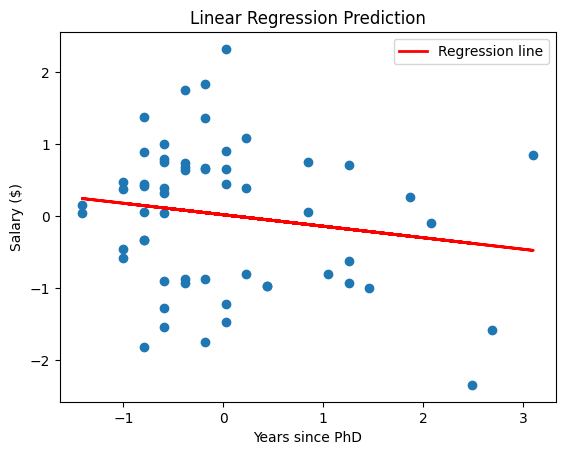

In [708]:
plt.scatter(x=df['yrs.since.phd'], y=df['salary'])

plt.plot(X_test, y_prediction, color='red', linewidth=2, label='Regression line')

plt.xlabel('Years since PhD')
plt.ylabel('Salary ($)')
plt.title('Linear Regression Prediction')
plt.legend()
# plt.grid(True)

In [709]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_prediction)
mse = mean_squared_error(y_test, y_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_prediction)


print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 (Coefficient of Determination): {r2}")

Mean Absolute Error (MAE): 0.8256238583280026
Mean Squared Error (MSE): 0.9647362236314032
Root Mean Squared Error (RMSE): 0.9822098674068609
R^2 (Coefficient of Determination): 0.07590014094005348
